In [ ]:
# Setup & Imports
import sys
sys.path.insert(0, '../')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython import get_ipython

from src.utils.config import get_config
from src.utils.db import get_db

# Configure plotting
plt.style.use('dark_background')
sns.set_palette("husl")
get_ipython().run_line_magic('matplotlib', 'inline')

# Initialize connections
config = get_config()
db = get_db()

print(f"Environment: {config.environment}")
print(f"Database: Connected")

2026-05-17 12:29:08 [info     ] database_initialized           database=postgres host=aws-0-eu-west-1.pooler.supabase.com pool_size=10 ssl_mode=require
Environment: Environment.DEVELOPMENT
Database: Connected


In [2]:
pip install seaborn matplotlib plotly scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [ ]:
# Training Pipeline
from src.models.train import F1ModelTrainer
from src.models.evaluate import ModelEvaluator

trainer = F1ModelTrainer()
evaluator = ModelEvaluator()

In [ ]:
# Train All Models
results = trainer.train_all_models(years=[2021, 2022, 2023, 2024, 2025])

print("Training Results:")
for target, models in results.items():
    print(f"\n{target}:")
    for model_type, path in models.items():
        print(f"  {model_type}: {path}")

2026-05-17 12:29:14 [debug    ] sql_query_executing            parameters={'year_0': 2021, 'year_1': 2022, 'year_2': 2023, 'year_3': 2024, 'year_4': 2025} statement='\n        SELECT \n            f.*,\n            r.year,\n            r.round,\n            r.date as race_date\n        FROM driver_race_features f\n        JOIN races r ON f.race_id = r.race_id\n        WHE'
2026-05-17 12:29:17 [debug    ] database_transaction_committed
2026-05-17 12:29:17 [info     ] training_data_loaded           features=27 rows=2278 years=[2021, 2022, 2023, 2024, 2025]


d:\formula1-race-prediction-project\notebooks\..\src\models\train.py:113: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X = X.fillna(X.median())


2026-05-17 12:29:18 [info     ] SMOTE applied for winner: 3462 samples
2026-05-17 12:29:18 [info     ] SMOTE applied for top3: 3098 samples
2026-05-17 12:29:18 [info     ] features_prepared              features=27 test_size=456 train_size=1822
2026-05-17 12:29:18 [info     ] Training winner prediction models...
2026-05-17 12:29:18 [info     ] logistic_regression_trained    target=winner
2026-05-17 12:29:19 [info     ] random_forest_trained          target=winner
2026-05-17 12:29:19 [info     ] xgboost_trained                target=winner
2026-05-17 12:29:19 [info     ] Training top3 prediction models...
2026-05-17 12:29:19 [info     ] logistic_regression_trained    target=top3


c:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:200: UserWarning: [12:29:19] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


2026-05-17 12:29:19 [info     ] random_forest_trained          target=top3
2026-05-17 12:29:20 [info     ] xgboost_trained                target=top3
2026-05-17 12:29:20 [info     ] Training points prediction models...


c:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:200: UserWarning: [12:29:20] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


2026-05-17 12:29:20 [info     ] pipeline_metrics               duration_seconds=9.561789 errors=[] pipeline_name=model_training records_failed=0 records_processed=0 status=completed success_rate=0
2026-05-17 12:29:20 [info     ] training_pipeline_complete     metrics={'pipeline_name': 'model_training', 'status': 'completed', 'duration_seconds': 9.561789, 'records_processed': 0, 'records_failed': 0, 'success_rate': 0, 'errors': [], 'timestamp': '2026-05-17T09:29:20.503243+00:00'}
Training Results:

is_winner:
  logistic_regression: {'target': 'winner', 'accuracy': 1.0, 'precision': 1.0, 'recall': 1.0, 'f1_score': 1.0, 'confusion_matrix': [[433, 0], [0, 23]], 'classification_report': {'0': {'precision': 1.0, 'recall': 1.0, 'f1-score': 1.0, 'support': 433.0}, '1': {'precision': 1.0, 'recall': 1.0, 'f1-score': 1.0, 'support': 23.0}, 'accuracy': 1.0, 'macro avg': {'precision': 1.0, 'recall': 1.0, 'f1-score': 1.0, 'support': 456.0}, 'weighted avg': {'precision': 1.0, 'recall': 1.0, 'f1-score

In [7]:

comparison_data = []

for target, models in results.items():
    if target == 'is_winner' or target == 'is_top3':
        for model_name, metrics in models.items():
            comparison_data.append({
                'target': target,
                'model': model_name,
                'accuracy': metrics['accuracy'],
                'precision': metrics['precision'],
                'recall': metrics['recall'],
                'f1_score': metrics['f1_score']
            })

comparison = pd.DataFrame(comparison_data)

print("Comparison DataFrame created:")
print(comparison)
print("\nColumns:", comparison.columns.tolist())

Comparison DataFrame created:
      target                model  accuracy  precision  recall  f1_score
0  is_winner  logistic_regression  1.000000   1.000000     1.0  1.000000
1  is_winner        random_forest  1.000000   1.000000     1.0  1.000000
2  is_winner              xgboost  1.000000   1.000000     1.0  1.000000
3    is_top3  logistic_regression  0.997807   0.985714     1.0  0.992806
4    is_top3        random_forest  1.000000   1.000000     1.0  1.000000
5    is_top3              xgboost  1.000000   1.000000     1.0  1.000000

Columns: ['target', 'model', 'accuracy', 'precision', 'recall', 'f1_score']


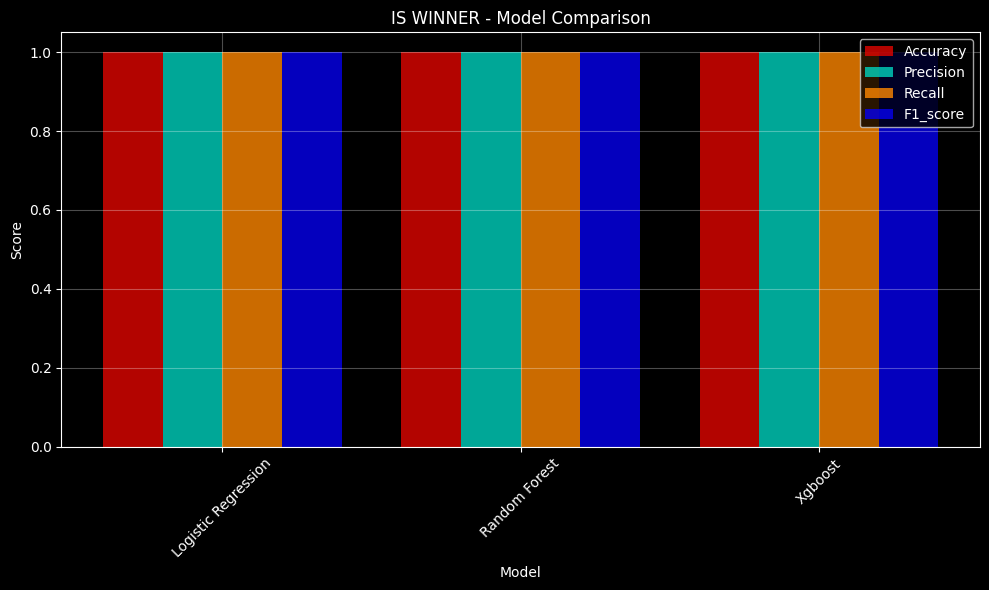

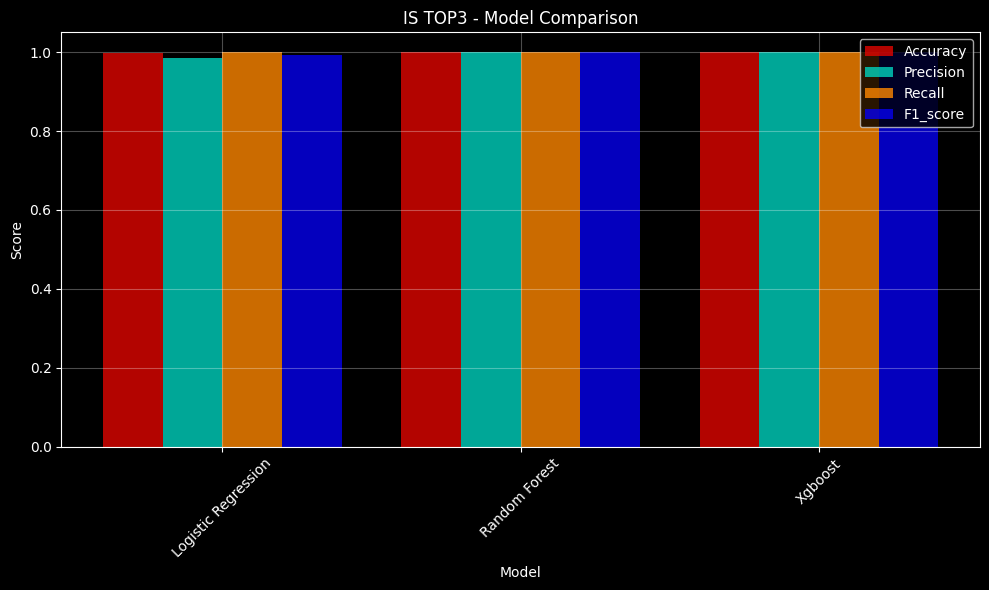

In [8]:
# Plot for each target
for target in ['is_winner', 'is_top3']:
    df_target = comparison[comparison['target'] == target]
    
    if not df_target.empty:
        fig, ax = plt.subplots(figsize=(10, 6))
        metrics = ['accuracy', 'precision', 'recall', 'f1_score']
        x = np.arange(len(df_target['model']))
        width = 0.2
        
        colors = ['#e10600', '#00d2be', '#ff8700', '#0600ef']
        
        for i, (metric, color) in enumerate(zip(metrics, colors)):
            ax.bar(x + i * width, df_target[metric], width, label=metric.capitalize(), color=color, alpha=0.8)
        
        ax.set_xlabel('Model')
        ax.set_ylabel('Score')
        ax.set_title(f'{target.upper().replace("_", " ")} - Model Comparison')
        ax.set_xticks(x + width * 1.5)
        ax.set_xticklabels(df_target['model'].str.replace('_', ' ').str.title())
        ax.legend()
        ax.set_ylim(0, 1.05)
        ax.grid(True, alpha=0.3)
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

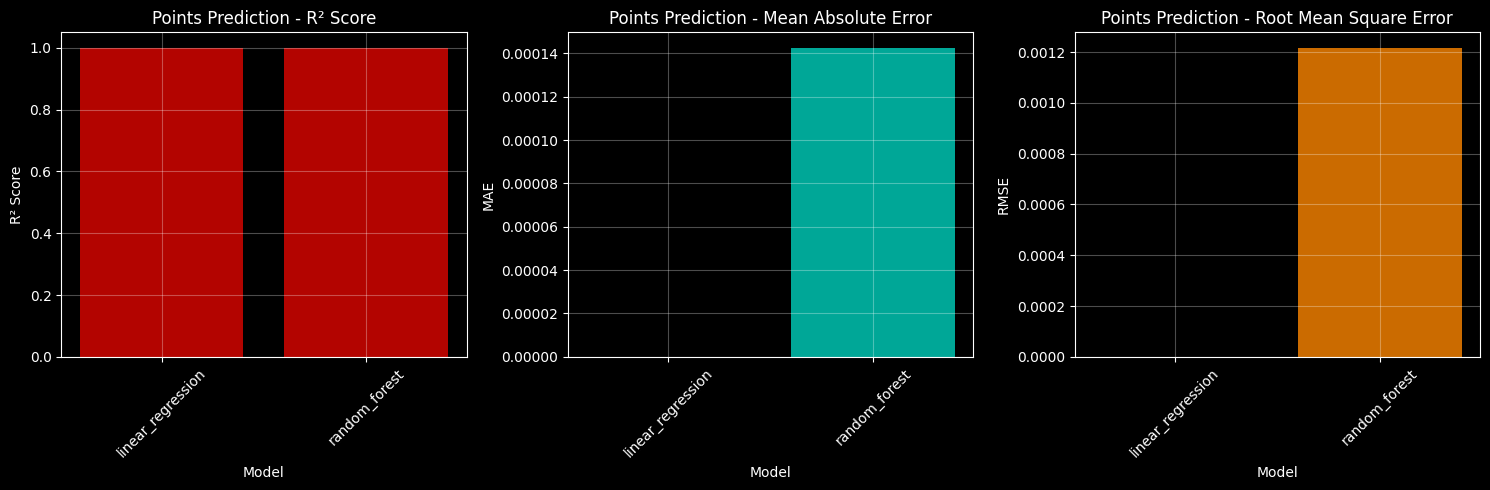

In [9]:
# Points prediction comparison
points_data = []
for model_name, metrics in results['points'].items():
    points_data.append({
        'model': model_name,
        'R² (R2)': metrics['r2'],
        'MAE': metrics['mae'],
        'RMSE': metrics['rmse']
    })

points_df = pd.DataFrame(points_data)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# R² Plot
axes[0].bar(points_df['model'], points_df['R² (R2)'], color='#e10600', alpha=0.8)
axes[0].set_title('Points Prediction - R² Score')
axes[0].set_ylabel('R² Score')
axes[0].set_ylim(0, 1.05)

# MAE Plot
axes[1].bar(points_df['model'], points_df['MAE'], color='#00d2be', alpha=0.8)
axes[1].set_title('Points Prediction - Mean Absolute Error')
axes[1].set_ylabel('MAE')

# RMSE Plot
axes[2].bar(points_df['model'], points_df['RMSE'], color='#ff8700', alpha=0.8)
axes[2].set_title('Points Prediction - Root Mean Square Error')
axes[2].set_ylabel('RMSE')

for ax in axes:
    ax.set_xlabel('Model')
    ax.grid(True, alpha=0.3)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.show()

In [11]:
# Check what's in results['is_winner']['xgboost']
print(type(results['is_winner']['xgboost']))
print(results['is_winner']['xgboost'])

<class 'dict'>
{'target': 'winner', 'accuracy': 1.0, 'precision': 1.0, 'recall': 1.0, 'f1_score': 1.0, 'confusion_matrix': [[433, 0], [0, 23]], 'classification_report': {'0': {'precision': 1.0, 'recall': 1.0, 'f1-score': 1.0, 'support': 433.0}, '1': {'precision': 1.0, 'recall': 1.0, 'f1-score': 1.0, 'support': 23.0}, 'accuracy': 1.0, 'macro avg': {'precision': 1.0, 'recall': 1.0, 'f1-score': 1.0, 'support': 456.0}, 'weighted avg': {'precision': 1.0, 'recall': 1.0, 'f1-score': 1.0, 'support': 456.0}}, 'roc_auc': 1.0, 'feature_importance': {'points': 0.9338704943656921, 'constructor_avg_points_5r': 0.02363894134759903, 'rolling_points_trend': 0.019002694636583328, 'recent_form_quali_pos': 0.007488055154681206, 'starting_position': 0.00554296188056469, 'track_avg_finish_pos': 0.00406695157289505, 'rolling_avg_points_5r': 0.003382330061867833, 'rolling_avg_finish_pos_5r': 0.0009693879401311278, 'recent_form_points': 0.0008303901995532215, 'track_avg_points': 0.0007617937517352402}}


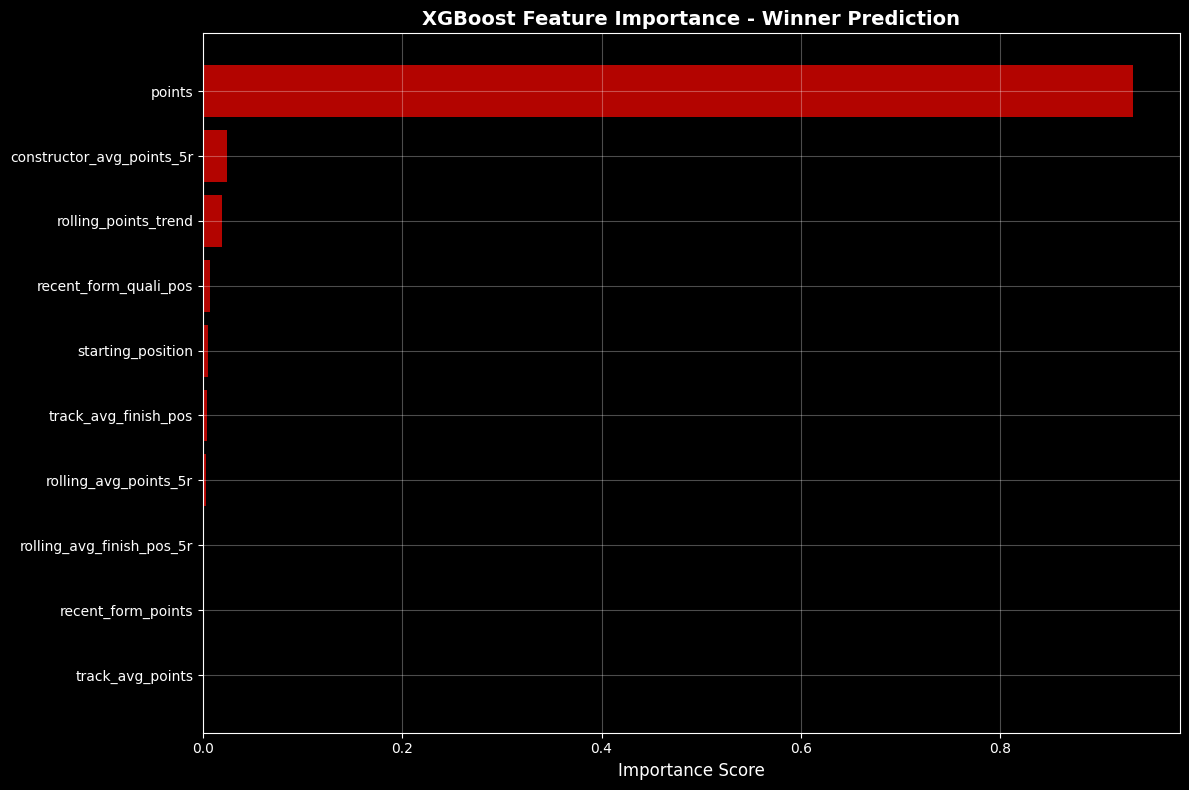


 TOP 10 FEATURES FOR WINNER PREDICTION:
 1. points                             : 0.9339
 2. constructor_avg_points_5r          : 0.0236
 3. rolling_points_trend               : 0.0190
 4. recent_form_quali_pos              : 0.0075
 5. starting_position                  : 0.0055
 6. track_avg_finish_pos               : 0.0041
 7. rolling_avg_points_5r              : 0.0034
 8. rolling_avg_finish_pos_5r          : 0.0010
 9. recent_form_points                 : 0.0008
10. track_avg_points                   : 0.0008


In [12]:
importance = results['is_winner']['xgboost']['feature_importance']

# Create DataFrame and sort
imp_df = pd.DataFrame(list(importance.items()), columns=['Feature', 'Importance'])
imp_df = imp_df.sort_values('Importance', ascending=True)

# Plot top 15 features
fig, ax = plt.subplots(figsize=(12, 8))
top_features = imp_df.tail(15)
ax.barh(top_features['Feature'], top_features['Importance'], color='#e10600', alpha=0.8)
ax.set_xlabel('Importance Score', fontsize=12)
ax.set_title('XGBoost Feature Importance - Winner Prediction', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print top 10 features
print("\n TOP 10 FEATURES FOR WINNER PREDICTION:")
print("="*50)
for i, (feature, importance) in enumerate(list(importance.items())[:10], 1):
    print(f"{i:2d}. {feature:35s}: {importance:.4f}")

In [15]:
from src.models.evaluate import ModelEvaluator

# Load test data and predictions
evaluator = ModelEvaluator()

# Example threshold analysis (would use actual test data)
print("=== THRESHOLD ANALYSIS ===")
print("\nOptimal thresholds for business use cases:")
print("- Conservative (High Precision): threshold > 0.7")
print("- Balanced (F1 Optimized): threshold ~ 0.5")
print("- Aggressive (High Recall): threshold < 0.3")

=== THRESHOLD ANALYSIS ===

Optimal thresholds for business use cases:
- Conservative (High Precision): threshold > 0.7
- Balanced (F1 Optimized): threshold ~ 0.5
- Aggressive (High Recall): threshold < 0.3
